In [5]:
#%cd NNtraining_simss
import tensorflow as tf
from tensorflow.keras.models import load_model
import os, json, glob, re, sys
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import joblib, uuid
import pandas as pd
from simss_utils.JV_steady_state import *
from copy import deepcopy
from scipy.stats.qmc import Sobol

def get_sample_name(path):
    filename = os.path.basename(path)
    # This regex looks for:
    # 1. Something like 'SOP' followed by alphanumeric characters
    # 2. A '#' followed by a digit
    match = re.search(r'04-(.*?)_.*_#(\d+)', filename)
    if match:
        return f"{match.group(1)}-{match.group(2)}"
    return filename # Fallback to filename if pattern fails

def preprocess_for_fit(v_sim, j_sim, target_v_start, target_v_end, step=0.02):
    """
    v_sim: original voltage array (e.g., -10 to 10)
    j_sim: original current density array
    """
    # 1. Define target grids
    v_target = np.arange(target_v_start, target_v_end+step, step)

    # 2. Create Interpolation function
    # Using 'linear' or 'cubic'; linear is safer for simulation data
    interp_func = interp1d(v_sim, j_sim, kind='linear', fill_value="extrapolate")

    # 3. Interpolate
    j_interp = interp_func(v_target)

    return j_interp

cwd = os.getcwd()
mydrive_path = 'NN_results'
reg_path = os.path.join(cwd,mydrive_path, '20260306-090915_two_defects_7p')
# model_path = os.path.join(reg_path,'y1', 'model.keras')
# regressor = load_model(model_path)
# scaler_path = os.path.join(reg_path,'20260306-090915_two_defects_7p_scaler.joblib')
# param_scaler = joblib.load(scaler_path)

res_dir = os.path.join(reg_path, 'SE04_2nd_round_fit')
num_samples = len(glob.glob(os.path.join(res_dir, 'fit*.png')))

json_path = os.path.join(reg_path, 'simulation_metadata.json')
with open(json_path, 'r') as f:
    metadata = json.load(f)
j_min, j_max = metadata['j_min'], metadata['j_max']
n_var = len(metadata['varied_parameters'].keys())
lb_mod = np.array([v[0] for v in metadata['varied_parameters_log'].values()])
ub_mod = np.array([v[1] for v in metadata['varied_parameters_log'].values()])

df_params = pd.read_csv(os.path.join(res_dir,'best_fit_parameters.csv'))
W_L, W_R_sclc, E_d_sh, N_t_sh, N_t_d, mu_e = df_params.iloc[0, num_samples:].values

trap_fn = os.path.join(cwd, 'SIMsalabim', 'SimSS', f"traps0.txt")
# Create trap file
with open(trap_fn, 'w') as f:
    f.write(f"E\tNtrap\n{E_d_sh}\t{N_t_sh}\n4.8\t{N_t_d}")

In [ ]:

exp_path = os.path.join(cwd, 'expData', '2024-01-04-B10n1 LowLight_JVi_#1_11.dat')
exp_data = np.loadtxt(exp_path, comments = '#')
target_v_start, target_v_end = 0, 1
exp_j_interp = preprocess_for_fit(exp_data[:,0], exp_data[:,1]*10*0.16/0.06, target_v_start, target_v_end)
v_target = np.arange(target_v_start, target_v_end+0.02, 0.02)

voltage_mask = exp_j_interp < 0
print(f"Data imported from {exp_path}")

fit_res_dir = os.path.join(res_dir, "fitJVi_exp11")
os.mkdir(fit_res_dir)
simss_device_parameters = os.path.join(cwd  ,"SIMsalabim" , "SimSS" , "simulation_setup.txt")
session_path= os.path.join(cwd  ,"SIMsalabim" , "SimSS")

Data imported from c:\Users\e.kim\Desktop\simS_sclc\NNtraining_simss\expData\2024-01-04-B10n1 LowLight_JVi_#1_11.dat


In [17]:
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

history_data = []
space = [
    Real(0, 0.3, name='W_R'),
    Real(5.3, 5.5, name = 'E_v'),
    Real(0.5, 1.0, name='G_frac'),
    Real(1e-18, 1e-14, prior='log-uniform', name='l1_k_dir'),
    Real(1e-18, 1e-12, prior='log-uniform', name='l1_C_n_bulk'),
    Real(1e-8, 1e-6, prior='log-uniform', name='l1_mu_p')
]

# 2. Define the Objective Function
@use_named_args(space)
def objective(W_R, E_v, G_frac, l1_k_dir, l1_C_n_bulk, l1_mu_p):
    ID = str(uuid.uuid4())
    JV_file_name = os.path.join(fit_res_dir, f'JV_{ID}.dat')
    logFile = os.path.join(fit_res_dir, f'log_{ID}.txt')

    # Construct parameters for SIMsalabim
    cmd_pars = [
        {'par': 'l1.L', 'val': str(130e-9)},
        {'par': 'W_L', 'val': str(W_L)},
        {'par': 'l1.bulkTrapFile', 'val': trap_fn},
        {'par': 'l1.mu_n', 'val': str(mu_e)},
        
        {'par':'dev_par_file','val':simss_device_parameters},
        {'par':'JVFile','val':JV_file_name},
        {'par':'logFile','val':logFile},
        {'par':'W_R', 'val': str(E_v-W_R)},
        {'par':'l1.E_v', 'val': str(E_v)},
        {'par':'G_frac', 'val': str(G_frac)},
        {'par':'l1.k_direct', 'val': str(l1_k_dir)},
        {'par': 'l1.C_n_bulk', 'val': str(l1_C_n_bulk)},
        {'par':'l1.mu_p', 'val': str(l1_mu_p)},
    ]

    try:
        # Run simulation
        utils_gen.run_simulation('simss', cmd_pars, session_path, True, verbose=False)
        Rpdark= [10.8, 34.6] 
        j_shunt_jvi = v_target[voltage_mask]/Rpdark[0] + v_target[voltage_mask]**2/Rpdark[1]
        # Load and calculate error
        data = pd.read_csv(JV_file_name, sep=r'\s+')
        max_j = np.max(np.abs(exp_j_interp[voltage_mask]))
        error = np.mean(np.abs(data['Jext'][voltage_mask] + j_shunt_jvi - exp_j_interp[voltage_mask])) / max_j
        
        # Cleanup unique files to save space
        if os.path.exists(JV_file_name): os.remove(JV_file_name)
        if os.path.exists(logFile): os.remove(logFile)
        history_data.append({
            'W_R': W_R,
            'E_v':E_v,
            'G_frac': G_frac,
            'l1_k_dir': l1_k_dir,
            'l1_C_n_bulk': l1_C_n_bulk,
            'l1_mu_p': l1_mu_p,
            'error': error
        })
        return error
    
    except Exception as e:
        print(f"Simulation failed for {ID}: {e}")
        return 9e9  # Return a very high penalty for crashes

# 3. Run the Optimization
res = gp_minimize(
    objective,              # the function to minimize
    space,                  # the bounds on each parameter
    n_calls=50,             # total number of simulations
    n_initial_points=10,    # how many random Sobol-like starts to do first
    random_state=42
)

pd.DataFrame(history_data).to_csv(os.path.join(fit_res_dir, 'optimization_history.csv'), index=False)

Simulation failed for 51ce56da-8694-4a22-8059-84870d818dc5: [Errno 2] No such file or directory: 'c:\\Users\\e.kim\\Desktop\\simS_sclc\\NNtraining_simss\\NN_results\\20260306-090915_two_defects_7p\\SE04_2nd_round_fit\\fitJVi_exp11\\JV_51ce56da-8694-4a22-8059-84870d818dc5.dat'
Simulation failed for 0ca11525-821e-4bfe-9bab-e659752e513c: [Errno 2] No such file or directory: 'c:\\Users\\e.kim\\Desktop\\simS_sclc\\NNtraining_simss\\NN_results\\20260306-090915_two_defects_7p\\SE04_2nd_round_fit\\fitJVi_exp11\\JV_0ca11525-821e-4bfe-9bab-e659752e513c.dat'
Simulation failed for fa651f06-b162-446c-b6d0-a5ff98d0e129: [Errno 2] No such file or directory: 'c:\\Users\\e.kim\\Desktop\\simS_sclc\\NNtraining_simss\\NN_results\\20260306-090915_two_defects_7p\\SE04_2nd_round_fit\\fitJVi_exp11\\JV_fa651f06-b162-446c-b6d0-a5ff98d0e129.dat'
Simulation failed for c3b50583-0f75-4514-af6d-78c1d0d48ce3: [Errno 2] No such file or directory: 'c:\\Users\\e.kim\\Desktop\\simS_sclc\\NNtraining_simss\\NN_results\\202

KeyboardInterrupt: 

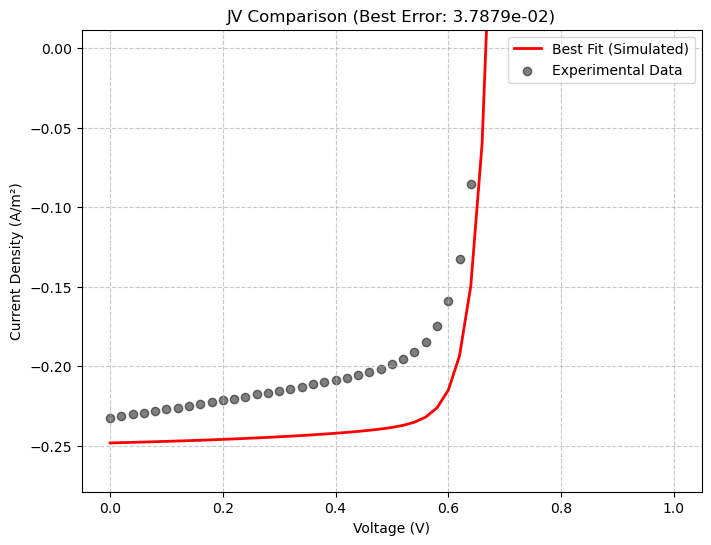

<Figure size 640x480 with 0 Axes>

In [ ]:
best_params = res.x
final_jv_path = os.path.join(fit_res_dir, 'best_fit_JV.dat')
log_path = os.path.join(fit_res_dir, 'best_fit_log.txt')

# Map best_params back to your simulation command
final_cmd = [
    {'par':'JVFile','val':final_jv_path},
    {'par':'logFile','val':log_path},
    {'par': 'l1.L', 'val': str(130e-9)},
    {'par': 'W_L', 'val': str(W_L)},
    {'par': 'l1.bulkTrapFile', 'val': trap_fn},
    {'par': 'l1.mu_n', 'val': str(mu_e)},
    {'par':'W_R', 'val': str(best_params[1]-best_params[0])},
    {'par':'l1.E_v', 'val': str(best_params[1])},
    {'par':'G_frac', 'val': str(best_params[2])},
    {'par':'l1.k_direct', 'val': str(best_params[3])},
    {'par':'l1.C_n_bulk', 'val': str(best_params[4])},
    {'par':'l1.mu_p', 'val': str(best_params[5])},
]

utils_gen.run_simulation('simss', final_cmd, session_path, True, verbose=False)
best_sim_data = pd.read_csv(final_jv_path, sep=r'\s+')
Rpdark= [10.8, 34.6] 
j_shunt_jvi =best_sim_data['Vext']/Rpdark[0] +best_sim_data['Vext']**2/Rpdark[1]
# 2. Visualize comparison
plt.figure(figsize=(8, 6))
plt.plot(best_sim_data['Vext'], best_sim_data['Jext'], 'r-', label='Best Fit (Simulated)', linewidth=2)
plt.scatter(v_target[voltage_mask], exp_j_interp[voltage_mask], c='k', label='Experimental Data', alpha=0.5)

plt.xlabel('Voltage (V)')
plt.ylabel('Current Density (A/m²)')
plt.title(f'JV Comparison (Best Error: {res.fun:.4e})')
plt.ylim(min(exp_j_interp[voltage_mask])*1.2, min(exp_j_interp[voltage_mask])*(-0.05))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
plt.savefig(os.path.join(fit_res_dir, 'fit_compare.png'), dpi=300)

In [19]:
LED_list_path = os.path.join('expData', 'LED_list.txt')
LED_list = np.loadtxt(LED_list_path, dtype=str)
sample_id = 'B10n1-1'
jv_charac = []
rerun = False
for LED_name in LED_list:
    final_jv_path = os.path.join(fit_res_dir, f'JV_best_fit_{LED_name}.dat')
    log_path = os.path.join(fit_res_dir, f'log_best_fit_{LED_name}.txt')
    scPars_path = os.path.join(fit_res_dir, f'scPars_best_fit_{LED_name}.dat')
    final_cmd = [
        {'par':'JVFile','val':final_jv_path},
        {'par':'scParsFile','val':scPars_path},
        {'par':'spectrum','val': f'../Data/LED_{LED_name}_{sample_id}.txt'},
        {'par': 'l1.L', 'val': str(130e-9)},
        {'par': 'W_L', 'val': str(W_L)},
        {'par': 'l1.bulkTrapFile', 'val': trap_fn},
        {'par': 'l1.mu_n', 'val': str(mu_e)},
        {'par':'W_R', 'val': str(best_params[0])},
        {'par':'G_frac', 'val': str(best_params[1])},
        {'par':'l1.k_direct', 'val': str(best_params[2])},
        {'par':'l1.C_n_bulk', 'val': str(best_params[3])},
        {'par':'l1.mu_p', 'val': str(best_params[4])},
    ]
    if rerun:
        utils_gen.run_simulation('simss', final_cmd, session_path, True, verbose=False)
    
    data = pd.read_csv(scPars_path,sep=r'\s+')
    jv_charac.append({
        'Jsc' : -data['Jsc'].values[0]/10, 'Voc': data['Voc'].values[0],
        'FF': data['FF'].values[0], 'MPP' : data['MPP'].values[0]/10        # convert A/m2 to mA/cm2
    })
df_results = pd.DataFrame(jv_charac)
output_filename = f'JV_characteristics_{sample_id}.csv'
output_path = os.path.join(fit_res_dir, output_filename)
df_results.to_csv(output_path, index=False)

exp_phivar_path = os.path.join('expData', 'phivar', f'{sample_id}_results.xlsx')
exp_phivar = pd.read_excel(exp_phivar_path,skiprows=[1,2])

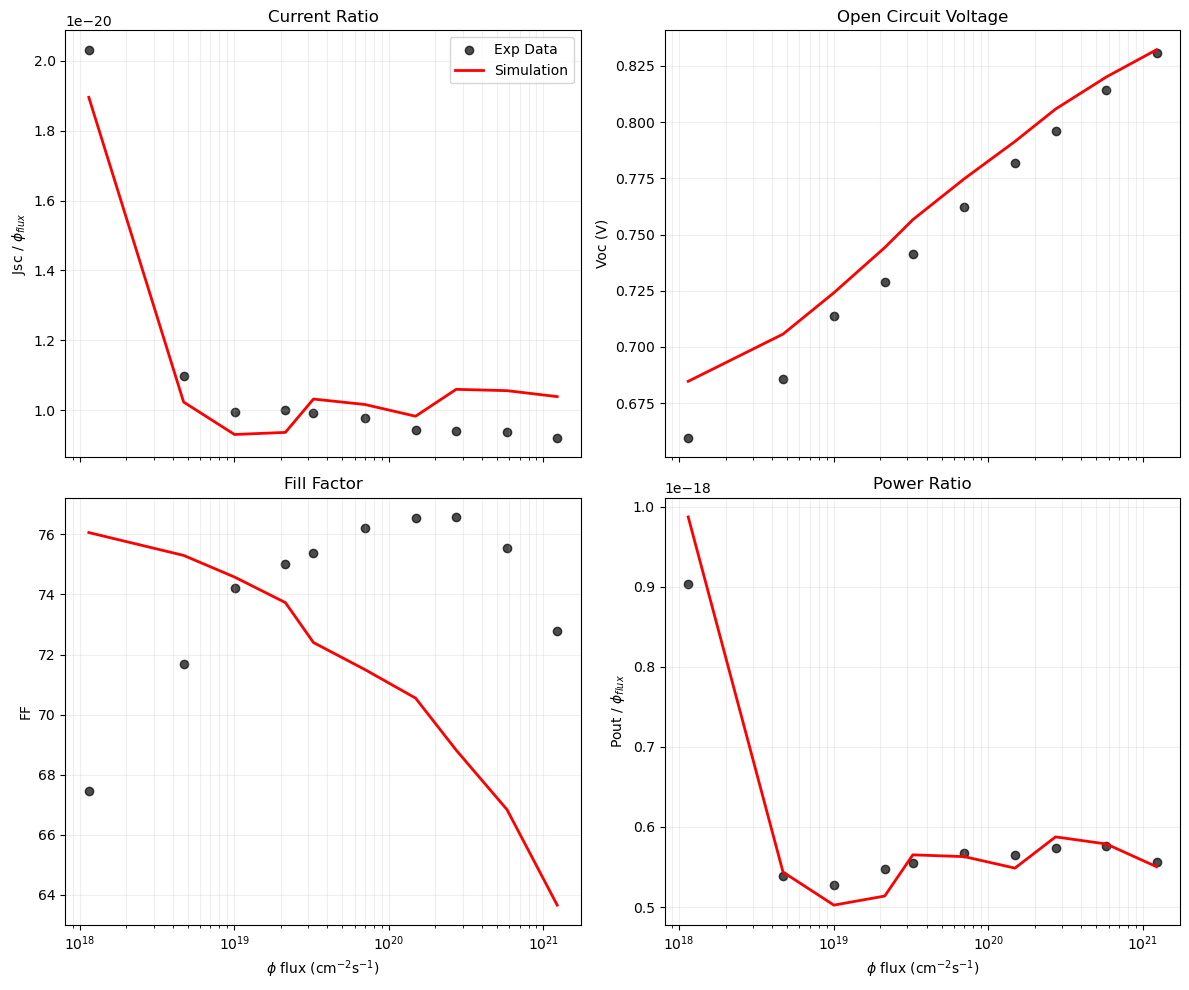

In [ ]:


# 1. Prepare the data
# We assume df_results and exp_phivar have the same number of rows and order
# Let's add the flux to our simulation results for easier plotting
df_results['phi_flux'] = exp_phivar['phi flux'].values
df_results['FF'] *= 100
# Calculate normalized values
# Experimental
exp_phivar['Jsc_norm'] = exp_phivar['Jsc'] / exp_phivar['phi flux']
exp_phivar['Pout_norm'] = (exp_phivar['Jsc'] * exp_phivar['Voc'] * exp_phivar['FF']) / exp_phivar['phi flux'] 

# Simulated (Assuming Jsc is in mA/cm^2 and Voc in V)
df_results['Jsc_norm'] = df_results['Jsc'] / df_results['phi_flux']
df_results['Pout_norm'] = (df_results['Jsc'] * df_results['Voc'] * df_results['FF']) / df_results['phi_flux']

# 2. Create the (2,2) Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

metrics = [
    ('Jsc_norm', 'Jsc / $\phi_{flux}$', 'Current Ratio'),
    ('Voc', 'Voc (V)', 'Open Circuit Voltage'),
    ('FF', 'FF', 'Fill Factor'),
    ('Pout_norm', 'Pout / $\phi_{flux}$', 'Power Ratio')
]

for i, (col, label, title) in enumerate(metrics):
    # Plot experimental data as scatter
    axes[i].scatter(exp_phivar['phi flux'], exp_phivar[col if col in exp_phivar else col], 
                    color='black', label='Exp Data', alpha=0.7)
    
    # Plot simulation results as a line
    axes[i].plot(df_results['phi_flux'], df_results[col], 
                 color='red', label='Simulation', linewidth=2)
    
    axes[i].set_ylabel(label)
    axes[i].set_xscale('log') # Intensity/Flux is usually best viewed on log scale
    axes[i].grid(True, which="both", ls="-", alpha=0.2)
    if i == 0:
        axes[i].legend()

axes[2].set_xlabel('$\phi$ flux (cm$^{-2}$s$^{-1}$)')
axes[3].set_xlabel('$\phi$ flux (cm$^{-2}$s$^{-1}$)')

plt.tight_layout()
plt.show()